# L-Maze: Comparison

## Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [1]:
import numpy as np
np.set_printoptions(precision=2)

In [2]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

## Define A L-Maze Grid World 

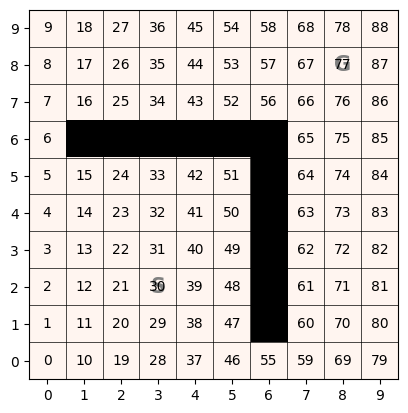

In [3]:
gym_env = gym.make('LMaze-v0')
env = gym_env.unwrapped

env.image()

In [4]:
# For comparison
cum_average_returns = {}

In [14]:
from gym_classics.performance import plot_returns, plot_ep_lens

## Monte Carlo Methods

MC Control (Incremental): 100%|██████████| 2000/2000 [00:00<00:00, 4797.82it/s]


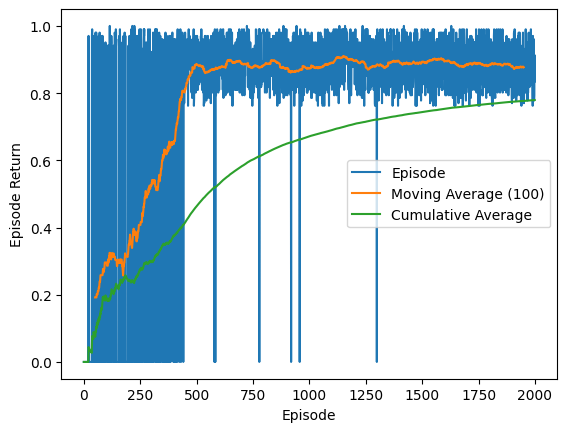

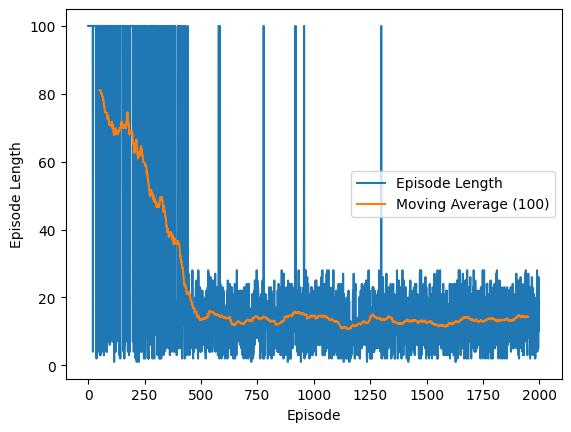

In [26]:
from gym_classics.algorithms.monte_carlo_methods import MC_control_ES

policy, Q, history = MC_control_ES(env, n=2000, discount=.99, history = True)

plot_returns(history["returns"])
plot_ep_lens([len(x) for x in history["episodes"]])

# We cannot use the results from exploring starts because episodes do not start from the start state
cum_average_returns["MC Control ES"] = np.nan 

## Tabular Temporal Differencing Methods

Sarsa: 100%|██████████| 2000/2000 [00:00<00:00, 2342.78it/s]


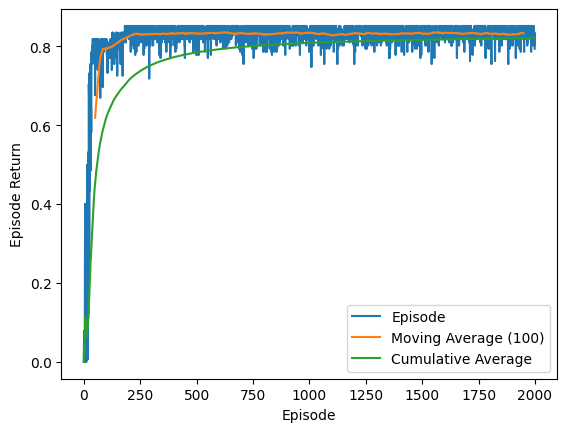

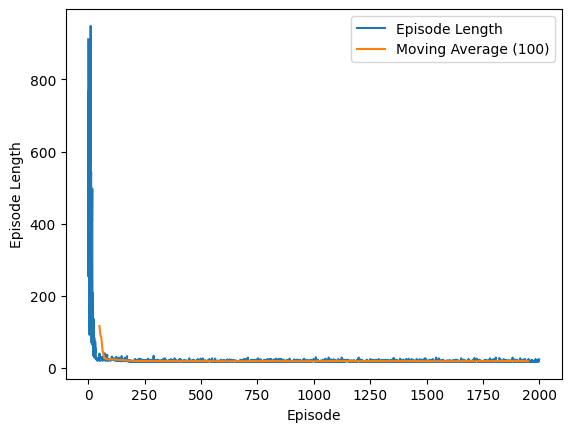

In [30]:
from gym_classics.algorithms.temporal_difference_learning import Sarsa

Q, history = Sarsa(env, n=2000, discount=.99, alpha = 0.01, epsilon = 0.1, history = True)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

cum_average_returns["Sarsa"] = np.sum(history["returns"])/len(history["returns"])

Q-Learning: 100%|██████████| 2000/2000 [00:01<00:00, 1820.76it/s]


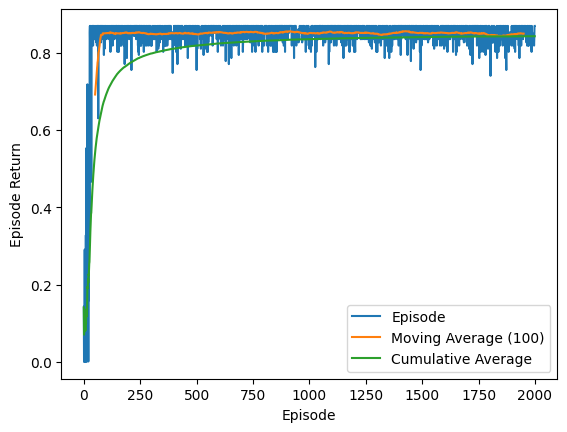

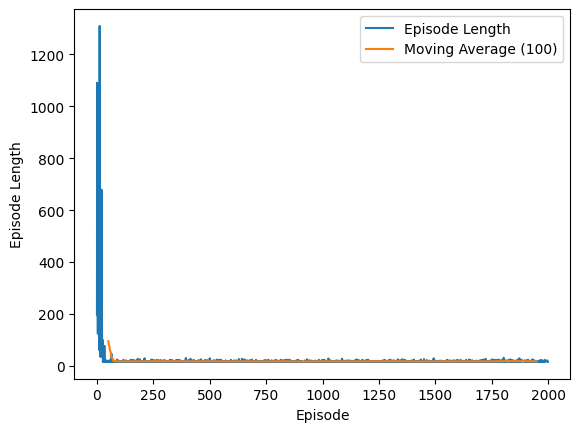

In [32]:
from gym_classics.algorithms.temporal_difference_learning import Q_learning

Q, history = Q_learning(env, n=2000, discount=.99, alpha = 0.01, epsilon = 0.1, history = True)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

cum_average_returns["Q-learning"] = np.sum(history["returns"])/len(history["returns"])

## Approximation Methods

In [18]:
from gym_classics.algorithms.linear_approximation import transformation_fourier_basis

trans_fb = transformation_fourier_basis(min = np.array([0,0]), max = env.dims, order=2)

# overwrite state_features for the semi-gradient Sarsa implementation with Fourier basis features
def state_features(s, env):
    return trans_fb(env.decode(s))

Semi-Gradient SARSA(0): 100%|██████████| 2000/2000 [00:05<00:00, 394.26it/s]


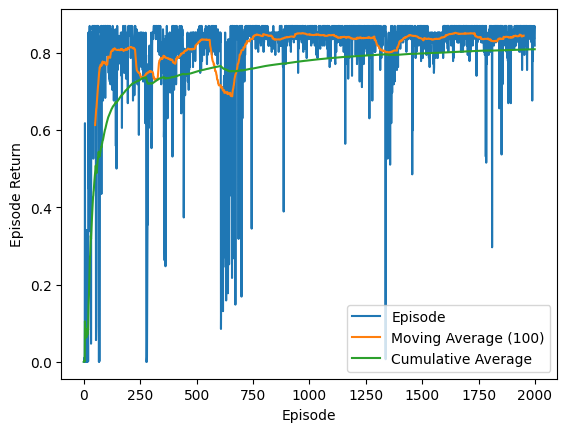

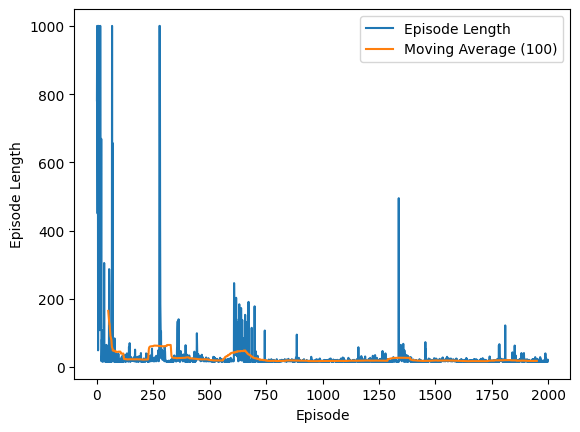

In [33]:
from gym_classics.algorithms.linear_approximation import semi_gradient_Sarsa_0
gym_classics.algorithms.linear_approximation.state_features = state_features

w, history = semi_gradient_Sarsa_0(env, n=2000, gamma=.99, alpha = 0.01, epsilon = 0.1, history = True)
plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

cum_average_returns["Semi-gradient Sarsa"] = np.sum(history["returns"])/len(history["returns"])

Semi-Gradient SARSA(lambda): 100%|██████████| 2000/2000 [00:09<00:00, 213.99it/s]


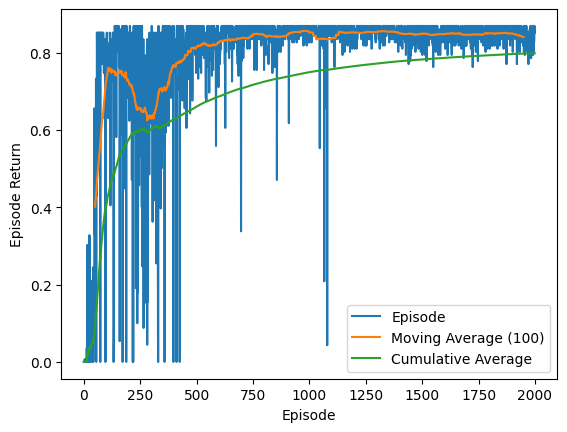

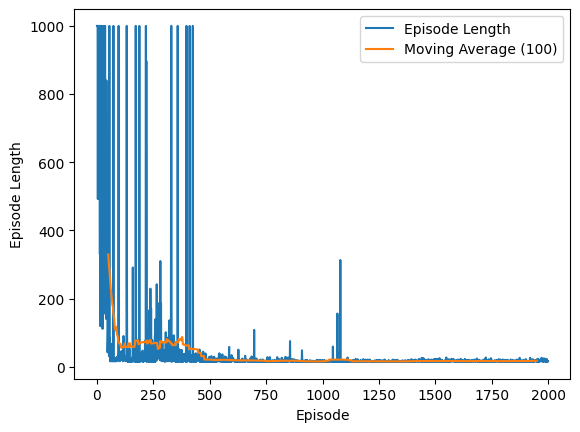

In [34]:
from gym_classics.algorithms.eligibility_traces import semi_gradient_Sarsa_lambda
gym_classics.algorithms.eligibility_traces.state_features = state_features

w, history = semi_gradient_Sarsa_lambda(env, n=2000, gamma=.99, lam = 0.5, alpha = 0.001, epsilon = 0.1, history = True, verbose = False)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

cum_average_returns["Semi-gradient Sarsa(lambda)"] = np.sum(history["returns"])/len(history["returns"])

Episodes: 100%|██████████| 2000/2000 [02:00<00:00, 16.55it/s]


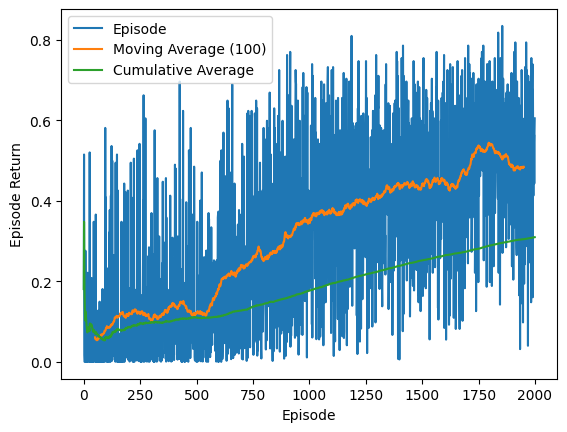

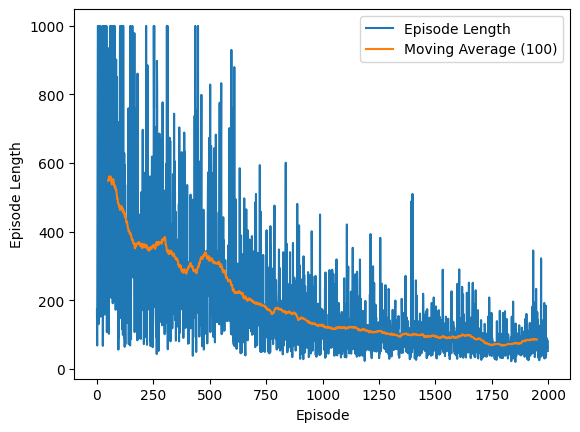

In [41]:
from gym_classics.algorithms.policy_gradient_methods import REINFORCE
gym_classics.algorithms.policy_gradient_methods.state_features = state_features

theta, history = REINFORCE(env, n= 2000, gamma=.99, alpha = .001, history = True, verbose = False)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

cum_average_returns["REINFORCE"] = np.sum(history["returns"])/len(history["returns"])

Note: May need a higher learning rate!

## Compare the Average Return


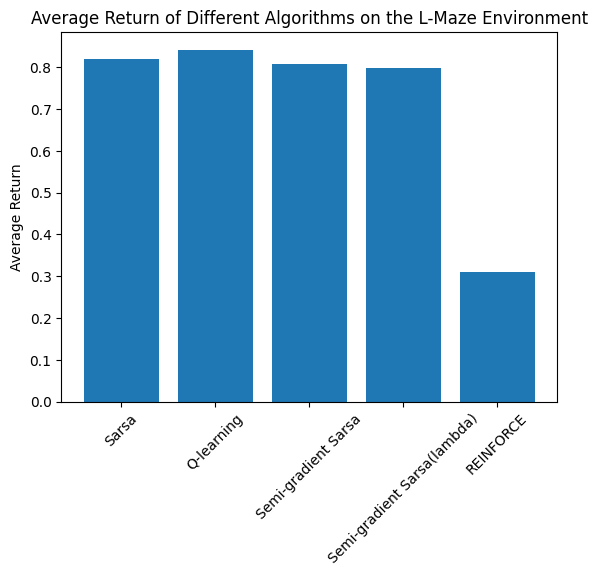

In [43]:
from matplotlib import pyplot as plt

plt.bar(cum_average_returns.keys(), cum_average_returns.values())
plt.ylabel("Average Return")
plt.title("Average Return of Different Algorithms on the L-Maze Environment")
plt.xticks(rotation=45)
plt.show()

## Deep Q-Networks (needs to be fixed)

**FIXME:** This does currently not work because gym_classics mazes do not return states as (x,y), but as an ID

In [5]:
%pip -q  install stable-baselines3 tqdm rich ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [11]:
from stable_baselines3 import DQN

model = DQN(
        "MlpPolicy",
        env,
        gamma = 0.99,
        target_update_interval=500,
        learning_rate=0.001,
        buffer_size=10000,
        exploration_fraction=.2,
        batch_size=32
    )

# total_timesteps (int) – The total number of samples (env steps) to train on. For comparison we use the data for 2000 episodes: 15 (opt. path length) * 2000
model.learn(total_timesteps=15 * 2000, log_interval=100, progress_bar=True)

Output()

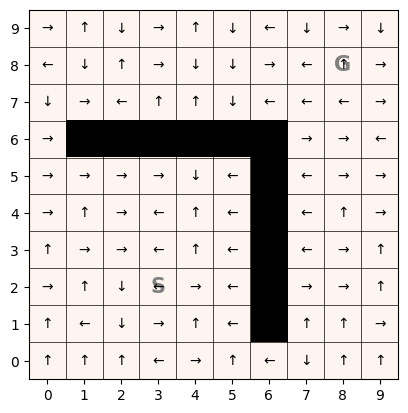

In [9]:
pol = [model.predict(s)[0] for s in range(env.observation_space.n)]
env.image(policy = pol)



&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)